In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chintooit/network1/cleaned_combined_all.csv


In [2]:
! pip install gdown 

In [3]:
!gdown id 1PYjOy4ZjLeAisC9PirVvlQ43z0qCXdlp

usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--fuzzy] [--id] [--proxy PROXY]
             [--speed SPEED] [--no-cookies] [--no-check-certificate]
             [--continue] [--folder] [--remaining-ok] [--format FORMAT]
             [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: 1PYjOy4ZjLeAisC9PirVvlQ43z0qCXdlp


In [4]:
df=pd.read_csv("/kaggle/input/datasets/chintooit/network1/cleaned_combined_all.csv")
df.head()

,fwd_iat_max,flow_iat_max,flow_iat_mean,idle_max,idle_std,fwd_iat_mean,fwd_iat_tot,idle_mean,flow_pkts_s,fwd_pkts_s,...,pkt_len_min,idle_min,pkt_len_std,fwd_pkt_len_std,fwd_seg_size_avg,fwd_pkt_len_mean,pkt_size_avg,pkt_len_mean,pkt_len_var,Class
0,14880209.0,14880209.0,3.085883e+06,11482205.0,3.800224e+06,3.085883e+06,58631778.0,3.547154e+06,0.341112,0.341112,...,88,20588.0,49.440141,49.440141,164.15,164.15,164.15,164.15,2.444328e+03,ARPSpoofing
1,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,...,100,0.0,0.000000,0.000000,100.00,100.00,100.00,100.00,0.000000e+00,ARPSpoofing
2,15028217.0,15028217.0,1.342785e+07,14999607.0,7.485498e+06,1.342785e+07,53711405.0,7.514108e+06,0.093090,0.093090,...,66,28610.0,0.000000,0.000000,66.00,66.00,66.00,66.00,0.000000e+00,ARPSpoofing
3,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,...,66,0.0,0.000000,0.000000,66.00,66.00,66.00,66.00,0.000000e+00,ARPSpoofing
4,15032639.0,15032639.0,5.643094e+06,9289740.0,3.934432e+06,5.643094e+06,50787843.0,3.758065e+06,0.196898,0.196898,...,66,33096.0,4372.919066,4372.919066,1544.20,1544.20,1544.20,1544.20,1.912242e+07,ARPSpoofing


In [5]:
import sys
if 'torch_geometric' not in sys.modules:
    !pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.7 MB/s eta 0:00:00


In [6]:
X = df.iloc[:, :-1]  # All columns except the last
y = df.iloc[:, -1]   # The last column as target


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import time

In [8]:
# Label encode the target variable if it's a string
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [10]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [11]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [12]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)


In [13]:

X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [14]:

# Custom Data Structure: UniqueOutputStructure
class UniqueOutputStructure:
    def __init__(self, liquid_states, spike_activity, time_dependent_memory):
        self.liquid_states = liquid_states
        self.spike_activity = spike_activity
        self.time_dependent_memory = time_dependent_memory  # Holds historical liquid states for richer classification

    def update_memory(self, new_liquid_state):
        # Update the time-dependent memory by shifting and adding new state
        self.time_dependent_memory.pop(0)
        self.time_dependent_memory.append(new_liquid_state)

    def get_full_representation(self):
        # Concatenates the current liquid states with historical states in memory for richer representation
        combined_states = torch.cat([self.liquid_states] + self.time_dependent_memory, dim=1)
        return combined_states

In [15]:
# Spike Encoding Layer
class SpikeEncodingLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super(SpikeEncodingLayer, self).__init__()
        self.fc = nn.Linear(input_size, output_size)

    def forward(self, x):
        return torch.relu(self.fc(x))

In [16]:
# Adaptive Liquid Layer (Dynamic Neuron Connections)
class AdaptiveLiquidLayer(nn.Module):
    def __init__(self, num_neurons):
        super(AdaptiveLiquidLayer, self).__init__()
        self.num_neurons = num_neurons
        self.connections = nn.Parameter(torch.randn(num_neurons, num_neurons))  # Learnable connections
        self.inhibition_mask = (torch.rand(num_neurons, num_neurons) > 0.7).float()  # Inhibitory connections

    def forward(self, spikes):
        inhibited_connections = self.connections * self.inhibition_mask
        activity = torch.matmul(spikes, inhibited_connections)
        return torch.tanh(activity)

# Attention-based Readout Layer
class AttentionReadoutLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super(AttentionReadoutLayer, self).__init__()
        self.attn = nn.Linear(input_size, 1)  # Attention weights
        self.fc = nn.Linear(input_size, output_size)

    def forward(self, x):
        attn_weights = F.softmax(self.attn(x), dim=1)
        x = x * attn_weights
        return self.fc(x)

In [17]:
# Full HLNN Model
class HybridLiquidNeuralNetwork(nn.Module):
    def __init__(self, input_size, spike_size, num_neurons, output_size):
        super(HybridLiquidNeuralNetwork, self).__init__()
        self.encoder = SpikeEncodingLayer(input_size, spike_size)
        self.liquid = AdaptiveLiquidLayer(num_neurons)
        self.readout = AttentionReadoutLayer(num_neurons, output_size)

    def forward(self, x):
        spikes = self.encoder(x)
        liquid_states = self.liquid(spikes)
        spike_activity = (liquid_states > 0).sum(dim=1)

        # Initialize the custom data structure with liquid states and spike activity
        time_dependent_memory = [torch.zeros_like(liquid_states)] * 5  # Initialize empty memory (5 historical states)
        unique_structure = UniqueOutputStructure(liquid_states, spike_activity, time_dependent_memory)

        return unique_structure

In [18]:
# Define parameters
n_input_features = X_train.shape[1]  # Number of input features
n_classes = len(set(y_train))  # Number of classes
spike_size = 50  # Number of neurons in the spike encoding
num_neurons = 50  # Number of neurons in the liquid layer

In [19]:
# Instantiate the HLNN model
hlnn_model = HybridLiquidNeuralNetwork(input_size=n_input_features, spike_size=spike_size, num_neurons=num_neurons, output_size=num_neurons)

In [20]:
import torch_geometric
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import dense_to_sparse
class GNNClassificationHead(nn.Module):
    def __init__(self, num_nodes_per_sample, node_feature_dim, hidden_dim, num_classes):
        super(GNNClassificationHead, self).__init__()
        self.num_nodes_per_sample = num_nodes_per_sample
        self.node_feature_dim = node_feature_dim

        # Pre-compute the adjacency matrix for a single fully connected graph
        # This will be used to construct batch-wise edge_index dynamically
        adj_single = torch.ones(self.num_nodes_per_sample, self.num_nodes_per_sample)
        # GCNConv adds self-loops by default, so we can keep the diagonal as 1 or 0 here.
        # Removing self-loops explicitly for GCNConv is a common practice if you want to avoid double-counting.
        # adj_single = adj_single - torch.eye(self.num_nodes_per_sample) # Uncomment to remove self-loops
        self.register_buffer('single_adj_matrix', adj_single)

        self.conv1 = GCNConv(node_feature_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, num_classes)

    def forward(self, hlnn_output_flat):
        # hlnn_output_flat shape: (batch_size, num_nodes_per_sample * node_feature_dim)
        batch_size = hlnn_output_flat.size(0)

        # Reshape to (batch_size * num_nodes_per_sample, node_feature_dim) for GNN node features
        x = hlnn_output_flat.view(batch_size * self.num_nodes_per_sample, self.node_feature_dim)

        # Create batch vector: indicates which graph each node belongs to
        batch = torch.arange(batch_size, device=x.device).repeat_interleave(self.num_nodes_per_sample)

        # Construct batch_edge_index
        # Convert single adjacency matrix to sparse edge_index once and cache it
        if not hasattr(self, '_single_edge_index_cached'):
            # Ensure the device is correct for `dense_to_sparse` input
            self._single_edge_index_cached = dense_to_sparse(self.single_adj_matrix.cpu())[0].to(x.device)

        # Repeat single_edge_index for each graph in the batch, adjusting node indices
        edge_indices_list = []
        for i in range(batch_size):
            edge_indices_list.append(self._single_edge_index_cached + i * self.num_nodes_per_sample)

        edge_index_batch = torch.cat(edge_indices_list, dim=1)

        # GCN layers
        x = F.relu(self.conv1(x, edge_index_batch))
        x = self.conv2(x, edge_index_batch) # Typically no ReLU before pooling/final layer

        # Global pooling layer to get a single graph-level representation for each sample
        # This collapses each graph into a single feature vector
        x = global_mean_pool(x, batch)

        # Linear layer for final classification
        return self.lin(x)

In [21]:
# Instantiate the GNN Classification Head
gnn_head = GNNClassificationHead(
    num_nodes_per_sample=num_neurons,
    node_feature_dim=6,
    hidden_dim=64, # Example hidden dimension for GNN layers
    num_classes=n_classes
)

In [22]:
# Redefine loss function and optimizer to include the new GNN head's parameters
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(hlnn_model.parameters()) + list(gnn_head.parameters()), lr=0.001)

In [23]:
print(X_train_tensor.shape)  # should be (N, features)
print(y_train_tensor.shape)

torch.Size([230904, 80])
torch.Size([230904])


In [24]:
# Create DataLoader for batching
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)


In [25]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

In [26]:
# Training loop (modified to use GNNClassificationHead)
num_epochs = 10

training_losses = [] # To store loss for plotting

for epoch in range(num_epochs):
    start_time = time.time()  # Start time tracking
    hlnn_model.train()
    gnn_head.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Forward pass through HLNN to get unique data structure (liquid states + metadata)
        unique_structure = hlnn_model(inputs)

        # Update time-dependent memory with new liquid state
        # This happens in-place in unique_structure's memory attribute
        unique_structure.update_memory(unique_structure.liquid_states.detach().clone()) # Detach and clone to prevent memory issues with graph operations

        # Get the full representation (current state + time-dependent memory)
        hlnn_output = unique_structure.get_full_representation()

        # Forward pass through GNN Classification Head
        outputs = gnn_head(hlnn_output)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # End time tracking for the epoch
    end_time = time.time()
    epoch_time = end_time - start_time  # Calculate elapsed time for the epoch

    avg_epoch_loss = running_loss / len(train_loader)
    training_losses.append(avg_epoch_loss)

    # Print loss and time for each epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}, Time: {epoch_time:.2f} seconds')

Epoch [1/10], Loss: 0.5530, Time: 258.61 seconds
Epoch [2/10], Loss: 0.3089, Time: 259.78 seconds
Epoch [3/10], Loss: 0.2435, Time: 262.44 seconds
Epoch [4/10], Loss: 0.2040, Time: 263.11 seconds
Epoch [5/10], Loss: 0.1802, Time: 224.67 seconds
Epoch [6/10], Loss: 0.1632, Time: 260.52 seconds
Epoch [7/10], Loss: 0.1527, Time: 259.12 seconds
Epoch [8/10], Loss: 0.1621, Time: 248.81 seconds
Epoch [9/10], Loss: 0.1390, Time: 258.28 seconds
Epoch [10/10], Loss: 0.1319, Time: 260.85 seconds


In [27]:

hlnn_model.eval()
gnn_head.eval()
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        # Forward pass through HLNN
        unique_structure = hlnn_model(inputs)
        # Update memory for consistency, though not strictly necessary for inference if memory is static
        unique_structure.update_memory(unique_structure.liquid_states)
        hlnn_output = unique_structure.get_full_representation()

        # Forward pass through GNN Classification Head
        outputs = gnn_head(hlnn_output)
        _, predicted = torch.max(outputs, 1)

        # Accumulate predictions and labels
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

In [28]:
# Calculate test accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 97.61%


In [29]:
torch.save(hlnn_model.state_dict(), '/hlnn_model.pth')
torch.save(gnn_head.state_dict(), '/gnn_head.pth')
print("Models saved successfully!")

Models saved successfully!


In [30]:
# Detailed classification report
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(all_labels, all_predictions, target_names=label_encoder.classes_))

                  precision    recall  f1-score   support

     ARPSpoofing       0.96      0.90      0.93      1833
       ICMPFlood       0.73      0.81      0.77       992
          OSScan       0.99      0.98      0.99     37484
        PortScan       1.00      0.99      1.00     76757
        SYNFLood       0.54      0.77      0.64       838
       UDP_flood       0.46      0.82      0.59       866
          benign       0.96      0.98      0.97      1587
dictionaryAttack       0.88      0.95      0.91      1296
        dnsflood       1.00      0.96      0.98     15823
   hostdiscovery       0.44      0.94      0.60       961
       pingsweep       0.99      0.95      0.97     10962
        slowiris       0.98      0.92      0.95      7712

        accuracy                           0.98    157111
       macro avg       0.83      0.92      0.86    157111
    weighted avg       0.98      0.98      0.98    157111



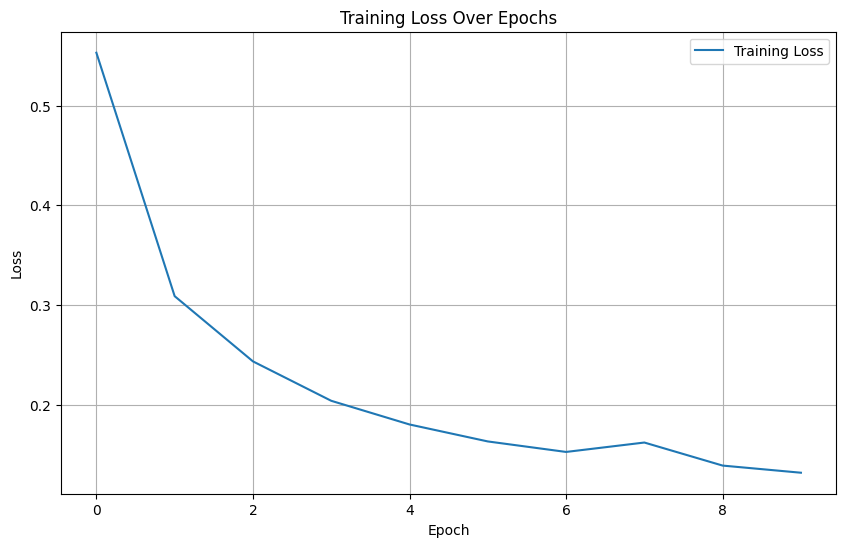

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
plt.savefig('my_plot.png')

<Figure size 640x480 with 0 Axes>

In [33]:
!ls

my_plot.png  __notebook__.ipynb
